In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import os
import torch
import torch.nn as nn
# torch.set_printoptions(edgeitems=10000)

In [3]:
import Training

title = 'BWBN_energy_Drucker'
hysteresis_data_dir = '/home/jaehwan/Python Project/DLCM/Testing_torch/Hysteresis'
n_samples = 80
Data = np.load(os.path.normpath(os.path.join(hysteresis_data_dir, './' + title + '_Processed_data.npz')))
X_train, X_val, y_train, y_val = Data['X_train'], Data['X_val'], Data['y_train'], Data['y_val']
del Data

normalize_gap = 0.1

X = []
y = []

time_length = []
num_inputs = 2 + 1
for i in range(n_samples):
    outputs = np.load(os.path.normpath(os.path.join(hysteresis_data_dir, './' + title + '_{}.npz'.format(i))))
    disp = outputs['disp']
    vel = outputs['vel']
    force = outputs['force']
    energy = outputs['energy']
    X.append(np.concatenate((disp[:, np.newaxis], vel[:, np.newaxis], np.ones((len(disp), 1))), axis=1))
    y.append(force)
    time_length.append(len(disp))
time_length = np.array(time_length)
max_time_length = np.max(time_length)
for i in range(n_samples):
    if len(X[i]) < max_time_length:
        X[i] = np.concatenate((X[i], np.zeros((max_time_length - len(X[i]), num_inputs))), axis=0)
        y[i] = np.concatenate((y[i], np.zeros((max_time_length - len(y[i])))), axis=0)
X, y = np.array(X), np.array(y)

if normalize_gap != False:
    X_max = np.max(np.abs(X), axis=(0,1))[:2]
    y_max = np.max(np.abs(y))
    X[:, :, :2] = X[:, :, :2] / (X_max * (1 + normalize_gap))
    y = y / (y_max * (1 + normalize_gap))



In [4]:
i = 0
f = y[i]
hysteresis = np.load(os.path.normpath(os.path.join(hysteresis_data_dir, title + '_{}.npz'.format(i))))
e = hysteresis['energy']
len_f, len_e = f.shape[0], e.shape[0]
padding_length = len_f - len_e
if padding_length > 0:
    e = np.concatenate((e, np.zeros((padding_length))), axis=0)
f, e = f[np.newaxis, :], e[np.newaxis, :]
f, e = torch.from_numpy(f).float(), torch.from_numpy(e).float()
mask = (X[i, :, 2])[np.newaxis, :]
mask = torch.from_numpy(mask).float()
print('Drucker\'s postulate loss function for {}-th sample:'.format(i), Training.drucker_loss(f, e, mask).item())

Drucker's postulate loss function for 0-th sample: 9.705762522571604e-07


In [5]:
f = y
f.shape

(80, 58399)

In [6]:
mask = (X[:, :, 2])
mask.shape

(80, 58399)

In [7]:
mask = torch.from_numpy(mask).float()

In [8]:

e_list = np.zeros(f.shape)
for i in range(n_samples):
    hysteresis = np.load(os.path.normpath(os.path.join(hysteresis_data_dir, title + '_{}.npz'.format(i))))
    e = hysteresis['energy']
    len_f, len_e = f[i].shape[0], e.shape[0]
    padding_length = len_f - len_e
    if padding_length > 0:
        e = np.concatenate((e, np.zeros((padding_length))), axis=0)
    e_list[i] = e




In [9]:
e_list[0]

array([3.24940323e-10, 8.24771073e-09, 5.39386561e-08, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [10]:
f = torch.from_numpy(f).float()
e = torch.from_numpy(e_list).float()

In [11]:
def drucker_loss(f, e, mask):
    
    num_samples, time_length = f.size()
    num_chops = 201
    chop_vector = torch.linspace(-1, 1, num_chops).to(f.device)

    # Expand the mask and tensors along the second axis
    mask_expanded = mask.unsqueeze(1).expand(-1, chop_vector.size(0), -1)
    f_expanded = f.unsqueeze(1).expand(-1, chop_vector.size(0), -1)
    e_expanded = e.unsqueeze(1).expand(-1, chop_vector.size(0), -1)

    chop_vector_expanded = chop_vector.unsqueeze(0).unsqueeze(-1).expand(num_samples, -1, time_length)
    deducted_f_expanded = f_expanded - chop_vector_expanded

    # Create deducted_f_sign tensor with size [num_samples, num_chops, time_length]
    deducted_f_sign = (deducted_f_expanded > 0).int()

    diff_sign = torch.diff(deducted_f_sign, dim=2, prepend=deducted_f_sign[:, :, 0].unsqueeze(2))
    change_bool = ((diff_sign != 0) * mask_expanded).bool()
    change_idx = torch.nonzero(change_bool)
    selected_e = e_expanded[change_idx[:, 0], change_idx[:, 1], change_idx[:, 2]]
    diff_e = selected_e[1:] - selected_e[:-1]
    diff_idx = change_idx[1:] - change_idx[:-1]
    diff_e = diff_e * (diff_idx[:, 0] == 0) * (diff_idx[:, 1] == 0)
    diff_e_neg = diff_e[diff_e < 0]
    return -torch.sum(diff_e_neg) / (num_samples * time_length)
    


In [13]:
drucker_loss(f, e, mask).item()

1.630489350645803e-06

In [12]:
Training.drucker_loss(f, e, mask).item()

1.630489350645803e-06

In [11]:

num_samples, time_length = f.size()
num_chops = 201
chop_vector = torch.linspace(-1, 1, num_chops).to(f.device)

# Expand the mask and tensors along the second axis
mask_expanded = mask.unsqueeze(1).expand(-1, chop_vector.size(0), -1)
f_expanded = f.unsqueeze(1).expand(-1, chop_vector.size(0), -1)
e_expanded = e.unsqueeze(1).expand(-1, chop_vector.size(0), -1)

chop_vector_expanded = chop_vector.unsqueeze(0).unsqueeze(-1).expand(num_samples, -1, time_length)
deducted_f_expanded = f_expanded - chop_vector_expanded

# Create deducted_f_sign tensor with size [num_samples, num_chops, time_length]
deducted_f_sign = (deducted_f_expanded > 0).int()

diff_sign = torch.diff(deducted_f_sign, dim=2, prepend=deducted_f_sign[:, :, 0].unsqueeze(2))
change_bool = ((diff_sign != 0) * mask_expanded).bool()


In [12]:
change_idx = torch.nonzero(change_bool)

In [13]:
selected_e = e_expanded[change_idx[:, 0], change_idx[:, 1], change_idx[:, 2]]

In [14]:
selected_e

tensor([6.8481e+00, 6.9004e+00, 1.8882e+01, 1.9205e+01, 5.9083e+00, 6.7065e+00,
        1.7922e+01, 1.9007e+01, 2.8166e+01, 2.8498e+01, 5.0734e+00, 6.5278e+00,
        1.7038e+01, 1.8802e+01, 2.1363e+01, 2.1835e+01, 2.7321e+01, 2.8258e+01,
        4.3571e+00, 6.3440e+00, 1.6237e+01, 1.8597e+01, 2.0642e+01, 2.1605e+01,
        2.1798e+01, 2.1995e+01, 2.6586e+01, 2.8007e+01, 7.8135e-01, 7.8962e-01,
        1.0909e+00, 1.1203e+00, 3.7840e+00, 6.1602e+00, 6.3624e+00, 6.5489e+00,
        1.5573e+01, 1.8383e+01, 2.0068e+01, 2.1753e+01, 2.5965e+01, 2.7770e+01,
        2.9262e-01, 3.2277e-01, 4.9364e-01, 4.9389e-01, 6.4502e-01, 7.2465e-01,
        9.2061e-01, 1.0479e+00, 3.3531e+00, 5.9784e+00, 6.0315e+00, 6.3441e+00,
        1.4976e+01, 1.8173e+01, 1.9565e+01, 2.1505e+01, 2.5457e+01, 2.7534e+01,
        3.1988e+01, 3.2060e+01, 2.1385e-01, 2.7047e-01, 4.0355e-01, 4.4137e-01,
        5.4074e-01, 6.7230e-01, 7.9848e-01, 9.9212e-01, 3.0212e+00, 6.1566e+00,
        1.4517e+01, 1.7991e+01, 1.9182e+

In [15]:
diff_e = selected_e[1:] - selected_e[:-1]
diff_idx = change_idx[1:] - change_idx[:-1]

In [19]:
diff_e = diff_e * (diff_idx[:, 0] == 0) * (diff_idx[:, 1] == 0)
diff_e_neg = diff_e[diff_e < 0]
drucker_loss = -torch.sum(diff_e_neg)

In [21]:
print((drucker_loss/(num_samples * time_length)).item())

9.705762522571604e-07


In [18]:
diff_idx[:, 1]

tensor([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [ ]:

selected_e = torch.where(change_idx, e_expanded, torch.full_like(e_expanded, float('nan')))

mask_no_nan = ~torch.isnan(selected_e)

# Change to chop_vector, num_samples, time_length
reordered_e = selected_e.permute(1, 0, 2)
reordered_mask = mask_no_nan.permute(1, 0, 2)

valid_indices = torch.stack(reordered_mask.nonzero(as_tuple=True), dim=-1)

valid_values = reordered_e[valid_indices[:, 0], valid_indices[:, 1], valid_indices[:, 2]]

diff_indices = valid_indices[1:] - valid_indices[:-1]
differences = (valid_values[1:] - valid_values[:-1]) * (diff_indices[:, 0] == 0) * (diff_indices[:, 1] == 0)

differences_neg = -differences
negative_values_only = (torch.abs(differences_neg) + differences_neg) / 2

return torch.sum(negative_values_only) / (num_samples * time_length)


In [5]:
num_samples, time_length = f.size()
num_chops = 201
chop_vector = torch.linspace(-1, 1, num_chops).to(f.device)
mask_expanded = mask.unsqueeze(2).expand(-1, -1, chop_vector.size(0))
f_expanded = f.unsqueeze(2).expand(-1, -1, chop_vector.size(0))
e_expanded = e.unsqueeze(2).expand(-1, -1, chop_vector.size(0))
chop_vector_expanded = chop_vector.unsqueeze(0).unsqueeze(0).expand(num_samples, time_length, -1)
deducted_f_expanded = f_expanded - chop_vector_expanded
# Create deducted_f_sign tensor with size [num_samples, time_length, num_chops]
deducted_f_sign = (deducted_f_expanded > 0).int()

diff_sign = torch.diff(deducted_f_sign, dim=1, prepend=deducted_f_sign[:, 0, :].unsqueeze(1))
change_idx = ((diff_sign != 0) * mask_expanded).bool()


In [8]:
torch.nonzero(change_idx)

tensor([[    0,    30,    50],
        [    0,   336,    50],
        [    0,   489,    50],
        [    0,   669,    50],
        [    0,   848,    50],
        [    0,   888,    49],
        [    0,   952,    49],
        [    0,  1015,    50],
        [    0,  1059,    51],
        [    0,  1097,    52],
        [    0,  1145,    53],
        [    0,  1195,    53],
        [    0,  1219,    52],
        [    0,  1238,    51],
        [    0,  1258,    50],
        [    0,  1278,    49],
        [    0,  1303,    48],
        [    0,  1398,    48],
        [    0,  1422,    49],
        [    0,  1445,    50],
        [    0,  1469,    51],
        [    0,  1496,    52],
        [    0,  1604,    52],
        [    0,  1627,    51],
        [    0,  1647,    50],
        [    0,  1671,    49],
        [    0,  1721,    48],
        [    0,  1837,    48],
        [    0,  1873,    49],
        [    0,  1899,    50],
        [    0,  1932,    51],
        [    0,  2113,    51],
        

In [9]:
sorted_indices = torch.argsort(torch.nonzero(change_idx)[:, -1])
sorted_idx = torch.nonzero(change_idx)[sorted_indices]

In [10]:
sorted_idx

tensor([[    0,  4718,    45],
        [    0,  4665,    45],
        [    0,  3565,    45],
        [    0,  3583,    45],
        [    0,  5148,    46],
        [    0,  4760,    46],
        [    0,  3509,    46],
        [    0,  3615,    46],
        [    0,  4624,    46],
        [    0,  5074,    46],
        [    0,  6294,    46],
        [    0,  6418,    46],
        [    0,  4600,    47],
        [    0,  2599,    47],
        [    0,  2620,    47],
        [    0,  3036,    47],
        [    0,  3067,    47],
        [    0,  4780,    47],
        [    0,  6258,    47],
        [    0,  3477,    47],
        [    0,  6468,    47],
        [    0,  5039,    47],
        [    0,  3651,    47],
        [    0,  3816,    47],
        [    0,  3888,    47],
        [    0,  5338,    47],
        [    0,  3088,    48],
        [    0,  8069,    48],
        [    0,  2649,    48],
        [    0, 10485,    48],
        [    0, 10396,    48],
        [    0,  2984,    48],
        

In [11]:
f[change_idx[:, :, 45]].size()

torch.Size([4])

In [8]:
idx = np.arange(time_length)

[]

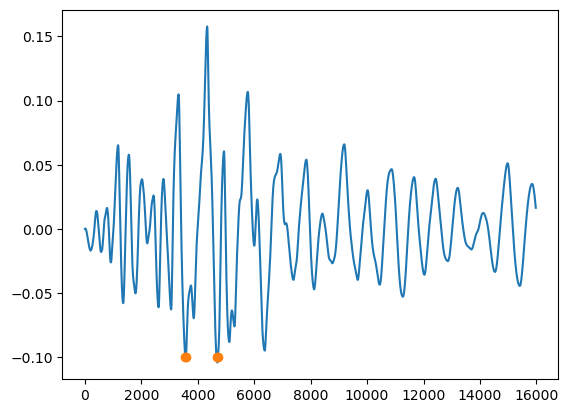

In [10]:
plt.plot(idx[mask[0, :].bool()], f[mask.bool()].numpy())
plt.plot(idx[change_idx[0, 90, :]], f[change_idx[:, 90, :]].numpy(), 'o')
plt.plot()

In [17]:

selected_e = torch.where(change_idx, e_expanded, torch.full_like(e_expanded, float('nan')))


In [25]:
torch.nonzero(change_idx)

tensor([[    0,    30,    50],
        [    0,   336,    50],
        [    0,   489,    50],
        [    0,   669,    50],
        [    0,   848,    50],
        [    0,   888,    49],
        [    0,   952,    49],
        [    0,  1015,    50],
        [    0,  1059,    51],
        [    0,  1097,    52],
        [    0,  1145,    53],
        [    0,  1195,    53],
        [    0,  1219,    52],
        [    0,  1238,    51],
        [    0,  1258,    50],
        [    0,  1278,    49],
        [    0,  1303,    48],
        [    0,  1398,    48],
        [    0,  1422,    49],
        [    0,  1445,    50],
        [    0,  1469,    51],
        [    0,  1496,    52],
        [    0,  1604,    52],
        [    0,  1627,    51],
        [    0,  1647,    50],
        [    0,  1671,    49],
        [    0,  1721,    48],
        [    0,  1837,    48],
        [    0,  1873,    49],
        [    0,  1899,    50],
        [    0,  1932,    51],
        [    0,  2113,    51],
        

In [19]:
selected_e[change_idx]

tensor([4.2586e-08, 9.9071e-04, 1.5594e-03, 2.7626e-03, 3.6720e-03, 3.1011e-02,
        3.1328e-02, 7.2883e-03, 3.5019e-02, 1.2005e-01, 2.8404e-01, 3.0241e-01,
        1.9044e-01, 1.2168e-01, 9.7746e-02, 1.2550e-01, 2.1385e-01, 2.7047e-01,
        2.0118e-01, 1.7682e-01, 2.0453e-01, 3.0156e-01, 3.6471e-01, 2.9544e-01,
        2.7032e-01, 3.0080e-01, 4.0355e-01, 4.4137e-01, 3.7003e-01, 3.4591e-01,
        3.7669e-01, 4.0732e-01, 3.8168e-01, 3.8265e-01, 4.1326e-01, 4.1906e-01,
        3.9305e-01, 4.2502e-01, 5.4074e-01, 7.8135e-01, 7.8962e-01, 6.7230e-01,
        5.9527e-01, 5.6789e-01, 6.0587e-01, 6.5325e-01, 6.2523e-01, 6.6306e-01,
        7.9848e-01, 1.0909e+00, 1.1203e+00, 9.9212e-01, 9.0060e-01, 8.7015e-01,
        9.2082e-01, 1.0972e+00, 1.4713e+00, 2.1536e+00, 3.2211e+00, 3.4602e+00,
        3.2049e+00, 2.9663e+00, 2.7484e+00, 2.5799e+00, 2.5164e+00, 2.6193e+00,
        3.0212e+00, 3.7840e+00, 5.0734e+00, 6.8481e+00, 6.9004e+00, 6.5278e+00,
        6.1602e+00, 6.3624e+00, 6.5489e+

In [20]:

mask_no_nan = ~torch.isnan(selected_e)


In [22]:
mask_no_nan.size()

torch.Size([1, 58399, 101])

In [ ]:
# Change to chop_vector, num_samples, time_length
reordered_e = selected_e.permute(2, 0, 1)
reordered_mask = mask_no_nan.permute(2, 0, 1)


In [31]:
reordered_mask.size()

torch.Size([101, 1, 58399])

In [32]:

valid_indices = torch.stack(reordered_mask.nonzero(as_tuple=True), dim=-1)


In [33]:
valid_indices.size()

torch.Size([228, 3])

In [ ]:

valid_values = reordered_e[valid_indices[:, 0], valid_indices[:, 1], valid_indices[:, 2]]


In [42]:
valid_indices[1:, :].size()

torch.Size([227, 3])

In [39]:

diff_indices = valid_indices[1:, :] - valid_indices[:-1, :]


In [40]:
diff_indices[:, 0].size()

torch.Size([227])

In [43]:

differences = (valid_values[1:] - valid_values[:-1]) * (diff_indices[:, 0] == 0) * (diff_indices[:, 1] == 0)

differences_neg = -differences
negative_values_only = (torch.abs(differences_neg) + differences_neg) / 2


In [57]:
(valid_values[1:]-valid_values[:-1])[154]

tensor(-0.0058)

In [61]:
valid_indices

tensor([[   45,     0,  3565],
        [   45,     0,  3583],
        [   45,     0,  4665],
        [   45,     0,  4718],
        [   46,     0,  3509],
        [   46,     0,  3615],
        [   46,     0,  4624],
        [   46,     0,  4760],
        [   46,     0,  5074],
        [   46,     0,  5148],
        [   46,     0,  6294],
        [   46,     0,  6418],
        [   47,     0,  2599],
        [   47,     0,  2620],
        [   47,     0,  3036],
        [   47,     0,  3067],
        [   47,     0,  3477],
        [   47,     0,  3651],
        [   47,     0,  3816],
        [   47,     0,  3888],
        [   47,     0,  4600],
        [   47,     0,  4780],
        [   47,     0,  5039],
        [   47,     0,  5338],
        [   47,     0,  6258],
        [   47,     0,  6468],
        [   48,     0,  1303],
        [   48,     0,  1398],
        [   48,     0,  1721],
        [   48,     0,  1837],
        [   48,     0,  2546],
        [   48,     0,  2649],
        

In [60]:
diff_indices[:, 0] == 0

tensor([ True,  True,  True, False,  True,  True,  True,  True,  True,  True,
         True, False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, 

In [58]:
differences[154]

tensor(-0.0058)

In [55]:
torch.nonzero(negative_values_only)

tensor([[111],
        [154]])

In [45]:
torch.sum(negative_values_only)

tensor(0.0327)

In [47]:
e.max()

tensor(33.7650)

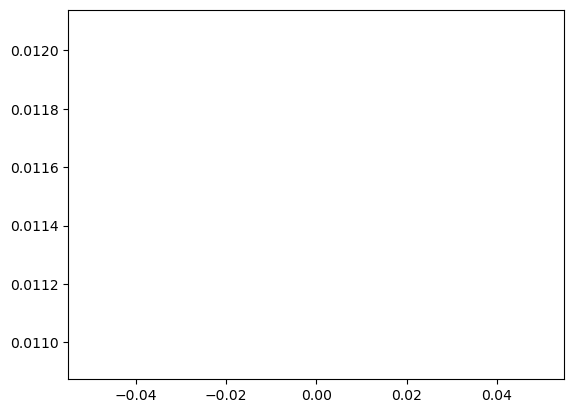

In [4]:
plt.plot(data['train_loss'])

In [5]:
data['train_loss']

array(0.01150642)

In [6]:
print(data['train_loss'])

0.011506416449350354


In [7]:
print(data['val_loss'])

[6.47788525 0.32590649 0.9923529  0.01719278 0.01179655 0.01279842
 0.02340997 0.03645056 0.04884535 0.06157193 0.07644315 0.08864272
 0.10331146 0.11802567 0.14241879 0.15348028 0.17221484 0.17839089
 0.21395704 0.22490717 0.24798751 0.26688579 0.30748248 0.31674916
 0.32367641 0.35458717 0.35746771 0.37469912 0.41173533 0.41509715
 0.41852945 0.42640626 0.43826249 0.43739676 0.4521386  0.45498848
 0.47529465 0.47479963 0.47322381 0.47410053 0.46285212 0.44524589
 0.43715546 0.43197265 0.42291969 0.42532533 0.42269409 0.41144922
 0.40229613 0.38383135 0.38453096 0.37644225 0.36875847 0.36355263
 0.35912567 0.35660827 0.35410717 0.35246378 0.34970558 0.34750259
 0.34567621 0.3434186  0.34218499 0.34666696 0.34560877 0.34514406
 0.3449128  0.34368485 0.34320608 0.34258565 0.34239152 0.34168953
 0.34134796 0.34092301 0.34032428 0.34017655 0.33956364 0.33870062
 0.33860722 0.33833632 0.33731237 0.3367852  0.33591464 0.33527851
 0.33471623 0.3342416  0.33409184 0.33404577 0.33414346 0.3340

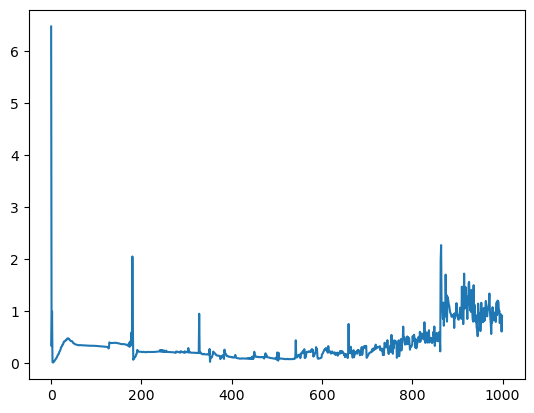

In [8]:
plt.plot(data['val_loss'])